# Particle movement in a simple model of a tokamak

In [1]:
from plasmapy import simulation
from plasmapy.formulary import magnetostatics
from plasmapy.classes.sources import Coils
import astropy.units as u
import numpy as np
radius = 1 * u.m
main_current = 15 * u.MA
plasma_wire = magnetostatics.CircularWire([0, 0, 1], u.Quantity((0, 0, 0), u.m), radius, main_current)

Let's visualize this coil using the awesome `pyvista` library.

Some pointers on installing it: TODO

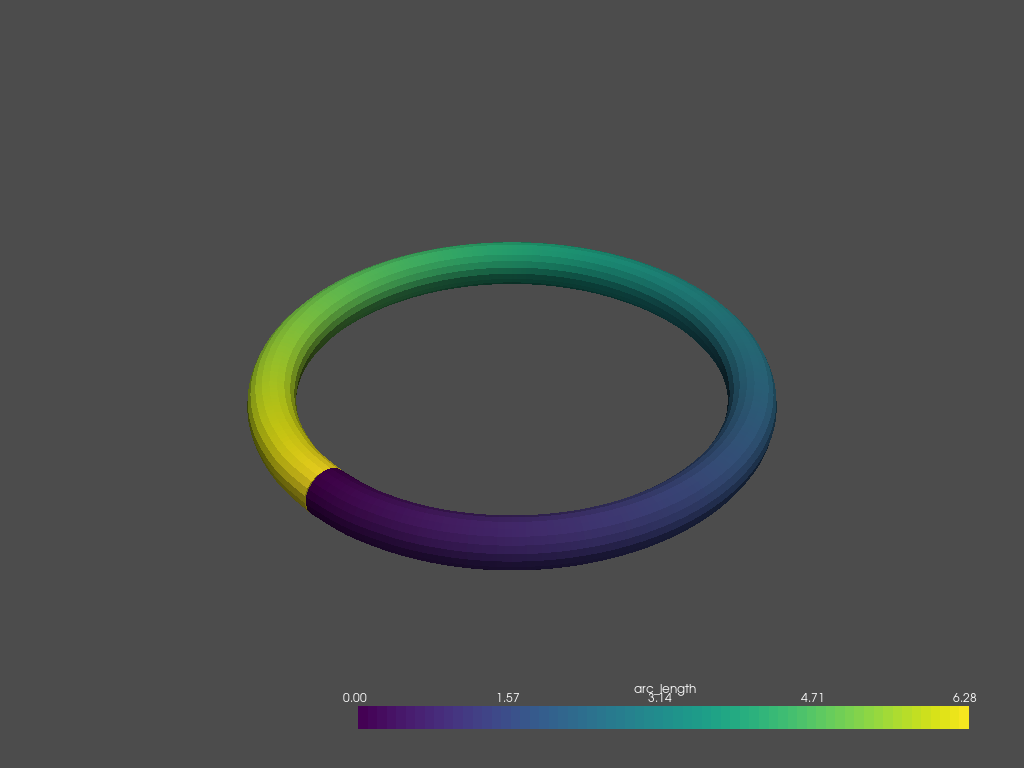

In [2]:
plasma_wire.visualize()

That's supposed to model just the plasma; let's add a few coils:

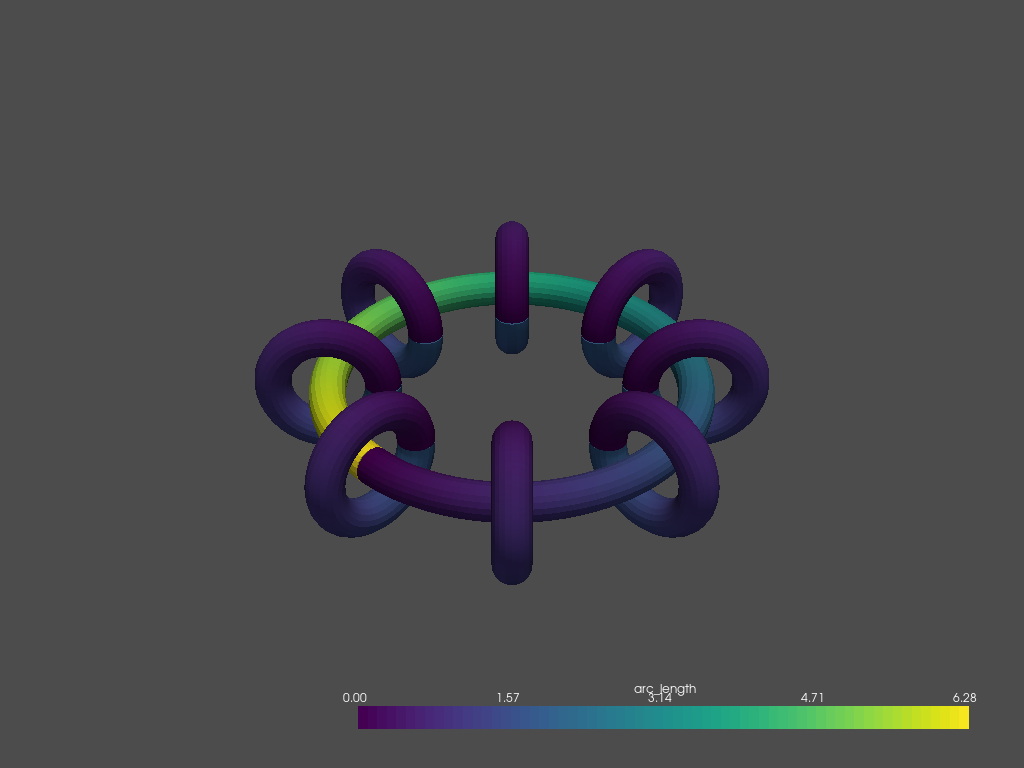

In [3]:
n_coils = 8
currents = u.Quantity(n_coils * [10], u.MA)

coil_angles = np.linspace(0, 2*np.pi, n_coils, endpoint=False)
coil_angles
minor_radius = 0.3 * u.m

coils = []
for i in range(n_coils):
    coil_angle = coil_angles[i]
    x = radius * np.cos(coil_angle)
    y = radius * np.sin(coil_angle)
    normal_angle = np.pi/2 + coil_angle
    normal = u.Quantity([np.cos(normal_angle), np.sin(normal_angle), 0])
    center = u.Quantity([x, y, 0 * u.m])
    coil = magnetostatics.CircularWire(normal, center, minor_radius, currents[i])
    coils.append(coil)
all_currents = coils + [plasma_wire]
c = Coils(*all_currents)
c.visualize()

TODO move to plasmapy.plasma.fields

In [8]:
Coils??

Init signature: Coils(*magnetostatics)
Source:        
class Coils(GenericPlasma):
    """
    Work-in-progress class for vacuum magnetic fields due to MagnetoStatics`.

    This is primarily helpful for `plasmapy.simulation.ParticleTracker`.
    """

    def __init__(self, *magnetostatics):
        self.magnetostatics = magnetostatics

    def _interpolate_E(self, r: u.m):
        return np.zeros(r.shape)
    
    def interpolate_E(self, r: u.m):
        return u.Quantity(self._interpolate_E(r.si.value), E_unit)
    
    def _interpolate_B(self, r):
        B = np.zeros(r.shape)
        for ms in self.magnetostatics:
            field = ms._magnetic_field(r, ms.pt, ms.dl, ms.current, ms.w)
            B += field
        return B

    def interpolate_B(self, r: u.m):
        return u.Quantity(self._interpolate_B(r.si.value), u.T)
        
    @classmethod
    def is_datasource_for(cls, **kwargs):
        match = 'interpolate_B' in kwargs.keys()
        return match

    def visualize(s

Note that a shortcut for this model can be quickly accessed as `Coils.toykamak`.

In [4]:
x = u.Quantity([[1 + minor_radius.si.value / 2, 0, 0]],  u.m)
v = u.Quantity([[0, 10000, 100]], u.m / u.s)

sim = simulation.ParticleTracker(c, x, v, 'e',)
solution = sim.run(1e-3 * u.s, dt = 1e-7 * u.s)
solution

In [5]:
import pyvista as pv
fig = pv.Plotter(notebook=True)
c.visualize(fig)
solution.visualize(fig)
fig.show(use_panel=True, auto_close = False)

VTK(vtkXOpenGLRenderWindow, height=400, sizing_mode='stretch_width')

In [11]:
solution.data

<xarray.Dataset>
Dimensions:    (dimension: 3, particle: 1, time: 10002)
Coordinates:
  * time       (time) float64 0.0 1e-07 2e-07 3e-07 ... 0.0009999 0.001 0.001
  * particle   (particle) int64 0
  * dimension  (dimension) <U1 'x' 'y' 'z'
Data variables:
    position   (time, particle, dimension) float64 1.15 -0.0005648 ... 0.09102
    velocity   (time, particle, dimension) float64 0.06818 ... 6.448e+03
    B          (time, particle, dimension) float64 1.887e-15 27.86 ... -12.82
    E          (time, particle, dimension) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    timestep   (time) float64 1e-07 1e-07 1e-07 1e-07 ... 1e-07 1e-07 1e-07
Attributes:
    particle:  e-

In [23]:
solution.data.sel(dimension='x', particle=0)

<xarray.Dataset>
Dimensions:    (time: 10002)
Coordinates:
  * time       (time) float64 0.0 1e-07 2e-07 3e-07 ... 0.0009999 0.001 0.001
    particle   int64 0
    dimension  <U1 'x'
Data variables:
    position   (time) float64 1.15 1.15 1.15 1.15 ... 1.149 1.149 1.149 1.149
    velocity   (time) float64 0.06818 28.92 49.05 ... -4.012e+03 4.268e+03
    B          (time) float64 1.887e-15 0.05155 0.1389 ... 2.132 2.09 2.121
    E          (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    timestep   (time) float64 1e-07 1e-07 1e-07 1e-07 ... 1e-07 1e-07 1e-07
Attributes:
    particle:  e-

In [33]:
from plasmapy.simulation.particletracker import ParticleTrackerSolution
ParticleTrackerSolution??

Init signature:
ParticleTrackerSolution(
    position_history: Unit("m"),
    velocity_history: Unit("m / s"),
    times: Unit("s"),
    b_history: Unit("T"),
    e_history: Unit("V / m"),
    particle: plasmapy.atomic.particle_class.Particle,
    diagnostics: list,
    dimensions='xyz',
)
Source:        
class ParticleTrackerSolution:
    """
    A solution to `ParticleTracker`'s trajectory integration.

    Parameters
    ----------
    x : `astropy.units.Quantity`
        Initial particle positions
    v : `astropy.units.Quantity`
        Initial particle velocities
    NT: int
        Number of time steps
    dt: `astropy.units.Quantity`
        time step length
    particle: `plasmapy.atomic.Particle`
        Particle type that underwent motion.

    Attributes
    ----------
    position_history : `astropy.units.Quantity`
        History of position, with units. Shape (nt, n, 3).
    velocity_history : `astropy.units.Quantity`
        History of velocity, with units. Shape (nt, n

In [31]:
solution.data.sel(dimension='x', particle=0)

<xarray.Dataset>
Dimensions:    (time: 10002)
Coordinates:
  * time       (time) float64 0.0 1e-07 2e-07 3e-07 ... 0.0009999 0.001 0.001
    particle   int64 0
    dimension  <U1 'x'
Data variables:
    position   (time) float64 1.15 1.15 1.15 1.15 ... 1.149 1.149 1.149 1.149
    velocity   (time) float64 0.06818 28.92 49.05 ... -4.012e+03 4.268e+03
    B          (time) float64 1.887e-15 0.05155 0.1389 ... 2.132 2.09 2.121
    E          (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    timestep   (time) float64 1e-07 1e-07 1e-07 1e-07 ... 1e-07 1e-07 1e-07
Attributes:
    particle:  e-

Let's see how the timestep affects the results' accuracy.

In the future, this should be alleviated by an adaptive time step.

In [ ]:
solution2 = sim.run(1e-3 * u.s, 1e-8 * u.s)

fig = pv.Plotter(notebook=True)
c.visualize(fig)
solution.visualize(fig)
fig.show(use_panel=True, auto_close = False)

In [ ]:
x = u.Quantity([[1 + minor_radius.si.value / 2, 0, 0]],  u.m)
v = u.Quantity([[10000, 10000, 1000000]], u.m / u.s)

banana_sim = simulation.ParticleTracker(c, x, v, 'e',)
banana_solution = banana_sim.run(1e-8 * u.s, 1e4)
banana_solution.plot_time_trajectories()
fig = mlab.figure(size=(800, 600))
c.visualize(fig)
banana_solution.visualize(fig)
mlab.orientation_axes(figure=fig)
fig

In [ ]:
solution2_unstable = sim.run(1e-4 * u.s, int(3e4))

fig = mlab.figure()
c.visualize(fig)
solution2_unstable.visualize(fig)
mlab.orientation_axes(figure=fig)
fig

In [ ]:
solution2_unstable.plot_time_trajectories()

In [ ]:
x2 = u.Quantity([[1 + minor_radius.si.value / 2, 0, 0]],  u.m)
v2 = u.Quantity([[0, 10000, 0]], u.m / u.s)

sim2 = simulation.ParticleTracker(c, x2, v2, 'e', )
solution3 = sim.run(1e-8 * u.s, int(3e5))

fig2 = mlab.figure()
c.visualize(fig2)
solution3.visualize(fig2)
mlab.orientation_axes(figure=fig2)
display(fig2)

In [ ]:
N = 30
xmany = u.Quantity(N*[[1 + minor_radius.si.value / 2, 0, 0]],  u.m)
vmany = np.array(N*[[0, 10000, 0]], dtype=float)
vmany[:, 2] = np.random.normal(size=N)
vmany = u.Quantity(vmany, u.m / u.s)

simmany = simulation.ParticleTracker(c, x2, v2, 'e', )
solutionmany = simmany.run(1e-8 * u.s, int(3e5))

fig2 = mlab.figure()
c.visualize(fig2)
solutionmany.visualize(fig2)
mlab.orientation_axes(figure=fig2)
display(fig2)

In [ ]:
solutionmany.plot_time_trajectories('xy') 

In [ ]:
solutionmany.plot_time_trajectories()